拆分被引证专利

In [115]:
!pip install --upgrade pandas pyreadstat

In [116]:
#打开文件
import pandas as pd

df = pd.read_stata("merge.dta")  # 打开文件
print(df.head())  # 显示前5行

         申请号  公开类型         公开公告号        申请日      公开公告日  \
0  001000020  发明授权    CN1123813C 2000-01-03 2003-10-08   
1  00100008X  发明授权    CN1142122C 2000-01-03 2004-03-17   
2  001000101  发明授权  CN100435848C 2000-01-03 2008-11-26   
3  001000152  发明授权    CN1087596C 2000-01-04 2002-07-17   
4  001000209  发明授权    CN1108235C 2000-01-04 2003-05-14   

                                               被引证专利  \
0  CN1696875A; CN100449464C; CN1295276A; CN101706...   
1     CN1326912A; CN1305977A; CN1120821C; CN1259286C   
2  CN101366949B; CN101366949A; CN104650184A; CN10...   
3                           CN100399936C; CN1666641A   
4                                                      

                                               被自引信息  \
0  CN1295276A; CN101408805A; CN1119739C; CN101908...   
1     CN1326912A; CN1305977A; CN1120821C; CN1259286C   
2                         CN101366949B; CN101366949A   
3                                                      
4                                 

In [117]:
#2查看数据结构

print("\n===== 数据结构信息 =====")
print(df.info())


===== 数据结构信息 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3617626 entries, 0 to 3617625
Data columns (total 11 columns):
 #   Column   Dtype         
---  ------   -----         
 0   申请号      object        
 1   公开类型     object        
 2   公开公告号    object        
 3   申请日      datetime64[ns]
 4   公开公告日    datetime64[ns]
 5   被引证专利    object        
 6   被自引信息    object        
 7   被他引信息    object        
 8   无效决定日    object        
 9   授权公告日    datetime64[ns]
 10  实质审查生效日  datetime64[ns]
dtypes: datetime64[ns](4), object(7)
memory usage: 303.6+ MB
None


In [118]:
import pandas as pd
import numpy as np

# ----------------------
# 1. 先把各种假空值 换成 NaN
# ----------------------
df = df.replace(["", " ", "nan", "NaN", "NULL", "null", "None"], np.nan)

# ----------------------
# 2. 统计每列真实缺失数量 + 百分比
# ----------------------
missing_report = pd.DataFrame({
    "缺失数量": df.isnull().sum(),
    "缺失比例(%)": round((df.isnull().sum() / len(df)) * 100, 2)
}).sort_values("缺失数量", ascending=False)

# 只显示有缺失的列
missing_report = missing_report[missing_report["缺失数量"] > 0]

print("每列真实缺失值统计（从多到少）：")
print(missing_report)

每列真实缺失值统计（从多到少）：
            缺失数量  缺失比例(%)
无效决定日    3610139    99.79
被自引信息    3446052    95.26
被他引信息    3082353    85.20
被引证专利    2955743    81.70
实质审查生效日     8549     0.24


In [119]:
#升序排列
df = df.sort_values(by=["被引证专利"], ascending=True)
df = df.dropna(how="all")
df

,申请号,公开类型,公开公告号,申请日,公开公告日,被引证专利,被自引信息,被他引信息,无效决定日,授权公告日,实质审查生效日
913321,2009102120454,发明授权,CN101699137B,2009-11-06,2011-04-06,AT12763U1,NaN,AT12763U1,NaN,2011-04-06,2010-06-23
133540,031052118,发明授权,CN1211718C,2003-02-21,2005-07-20,AT13926U1,NaN,AT13926U1,NaN,2005-07-20,2004-01-28
858801,2009101001937,发明授权,CN101606755B,2009-06-27,2011-11-09,AT13934U1; US9277766B2,NaN,AT13934U1; US9277766B2,NaN,2011-11-09,2010-02-17
317359,2005100461155,发明授权,CN100444763C,2005-03-25,2008-12-24,AT14249U1,NaN,AT14249U1,NaN,2008-12-24,2007-01-10
2345907,2014105399944,发明授权,CN104405128B,2014-10-14,2016-07-13,AT15506U1,NaN,AT15506U1,NaN,2016-07-13,2015-04-08
...,...,...,...,...,...,...,...,...,...,...,...
3617616,998170909,发明授权,CN1229886C,1999-12-06,2005-11-30,NaN,NaN,NaN,NaN,2005-11-30,2003-05-14
3617617,998170917,发明授权,CN1254927C,1999-12-17,2006-05-03,NaN,NaN,NaN,NaN,2006-05-03,2003-05-14
3617619,998170933,发明授权,CN1264057C,1999-12-17,2006-07-12,NaN,NaN,NaN,NaN,2006-07-12,2003-05-28
3617623,99817100X,发明授权,CN1174008C,1999-10-14,2004-11-03,NaN,NaN,NaN,NaN,2004-11-03,2003-05-28


In [120]:
df = df[df["被引证专利"].str.contains("CN", na=False)]

# 查看结果
print("筛选后剩余行数：", len(df))
df.head(10)

筛选后剩余行数： 607852


,申请号,公开类型,公开公告号,申请日,公开公告日,被引证专利,被自引信息,被他引信息,无效决定日,授权公告日,实质审查生效日
1254124,2011101513754,发明授权,CN102329000B,2011-06-08,2013-01-16,AT15789U3; CN109557273A; CN109557273B,NaN,AT15789U3; CN109557273A; CN109557273B,NaN,2013-01-16,2012-03-14
1529900,2012102154166,发明授权,CN102703155B,2012-06-27,2014-05-28,AT16026U1; AT518625A3; CN106753648A,NaN,AT16026U1; AT518625A3; CN106753648A,NaN,2014-05-28,2012-11-28
854737,2009100929905,发明授权,CN101690468B,2009-09-21,2011-09-21,AT16840U1; CN203618545U,NaN,AT16840U1; CN203618545U,NaN,2011-09-21,2010-05-26
2635825,2015102935751,发明授权,CN104902594B,2015-06-01,2017-01-18,AT16953U1; CN206136330U,CN206136330U,AT16953U1,NaN,2017-01-18,2015-10-07
672236,2008100350813,发明授权,CN101545018B,2008-03-25,2011-07-20,AT515588A1; CN108220510A; CN114317870A,CN108220510A; CN114317870A,AT515588A1,NaN,2011-07-20,2009-11-25
1809608,2013101381491,发明授权,CN103190313B,2013-04-19,2014-12-10,AT519027A1; AT519027B1; CN205830694U; CN105961...,NaN,AT519027A1; AT519027B1; CN205830694U; CN105961...,NaN,2014-12-10,2013-08-07
2122430,2014100107719,发明授权,CN103741717B,2014-01-09,2016-04-20,AT519368B1; AT519368A4; CN105780810A; CN206337...,NaN,AT519368B1; AT519368A4; CN105780810A; CN206337...,NaN,2016-04-20,2014-05-21
2253441,2014103118414,发明授权,CN104077842B,2014-07-02,2017-02-15,AT520332A4; AT520332B1; CN109830072A,NaN,AT520332A4; AT520332B1; CN109830072A,NaN,2017-02-15,2014-10-29
2386872,2014106684438,发明授权,CN104463167B,2014-11-20,2017-08-25,AT520332B1; CN109389753A; AT520332A4,NaN,AT520332B1; CN109389753A; AT520332A4,NaN,2017-08-25,2015-04-22
1834149,2013101895298,发明授权,CN103286471B,2013-05-21,2015-08-19,AT521774B1; AT521774A4; CN109732239A; CN109732...,NaN,AT521774B1; AT521774A4; CN109732239A; CN109732...,NaN,2015-08-19,2013-11-27


In [121]:
# 保存为 CSV（中文无乱码，兼容所有软件）
df.to_csv("merge_clean.csv", index=False, encoding="utf-8-sig")

print("已保存为 CSV 文件：merge_clean.csv")

已保存为 CSV 文件：merge_clean.csv


In [122]:
# 保存为新版 dta 文件，支持长字符串（不行 仅支持旧版本的 stata）
df.to_stata(
    "merge_clean.dta",
    write_index=False,
    version=117  # 对应 Stata 13+ 格式，支持 2045 字符的字符串
)

print("✅ 已成功保存为新版 dta 文件：merge_clean.dta")

/var/folders/gp/phhsd4211_16m7zsfp4l8bv00000gn/T/ipykernel_32500/470618357.py:2: InvalidColumnName: 
Not all pandas column names were valid Stata variable names.
The following replacements have been made:

    申请号   ->   ___
    公开类型   ->   ____
    公开公告号   ->   _____
    申请日   ->   _0___
    公开公告日   ->   _1_____
    被引证专利   ->   _2_____
    被自引信息   ->   _3_____
    被他引信息   ->   _4_____
    无效决定日   ->   _5_____
    授权公告日   ->   _6_____
    实质审查生效日   ->   _______

If this is not what you expect, please make sure you have Stata-compliant
column names in your DataFrame (strings only, max 32 characters, only
alphanumerics and underscores, no Stata reserved words)

  df.to_stata(


UnicodeEncodeError: 'latin-1' codec can't encode characters in position 0-3: ordinal not in range(256)

In [ ]:
df = df[["申请号", "被引证专利"]].copy()

# ----------------------
# 3. 去除空值行（必须！不然会报错）
# ----------------------
df = df.dropna(subset=["被引证专利"])

# ----------------------
# 4. ✅ 核心：拆分 → 变多行（你最想要的功能）
# ----------------------
# 按分号 ; 拆分，并展开成多行
df_expand = df.assign(被引证专利=df["被引证专利"].str.split(";")).explode("被引证专利")

# ----------------------
# 5. 清理空格（非常重要！）
# ----------------------
df_expand["被引证专利"] = df_expand["被引证专利"].str.strip()

# ----------------------
# 6. 再次删除空值（清理拆分后产生的空行）
# ----------------------
df_expand = df_expand[df_expand["被引证专利"] != ""].copy()
df_cn = df_expand[df_expand["被引证专利"].str.startswith("CN")].copy()
df_cn["被引证专利"] = df_cn["被引证专利"].str.replace(r"^CN", "", regex=True)
df_cn.to_csv("merge_clean_split_cn.csv", index=False, encoding="utf-8-sig")

print("完成了")
print(df_cn.head())

完成了
             申请号       被引证专利
0  2011101513754  109557273A
0  2011101513754  109557273B
1  2012102154166  106753648A
2  2009100929905  203618545U
3  2015102935751  206136330U


被引证专利对应申请年份

In [ ]:
import pandas as pd
import numpy as np

# 读取数据
df_clean = pd.read_csv("merge_clean.csv")

# ----------------------
# 1. 修正：必须用 pd.to_datetime，不是 df_clean.to_datetime
# ----------------------
df_clean["申请日"] = pd.to_datetime(df_clean["申请日"], errors="coerce")
df_clean["公开公告日"] = pd.to_datetime(df_clean["公开公告日"], errors="coerce")
df_clean["授权公告日"] = pd.to_datetime(df_clean["授权公告日"], errors="coerce")

# ----------------------
# 2. 拆分年份和季度
# ----------------------
# 申请日
df_clean["申请年"] = df_clean["申请日"].dt.year
df_clean["申请季度"] = df_clean["申请日"].dt.to_period("Q").astype(str) 
# 公开公告日
df_clean["公开年"] = df_clean["公开公告日"].dt.year
df_clean["公开季度"] = df_clean["公开公告日"].dt.to_period("Q").astype(str)

# 授权公告日
df_clean["授权年"] = df_clean["授权公告日"].dt.year
df_clean["授权季度"] = df_clean["授权公告日"].dt.to_period("Q").astype(str)

# ----------------------
# 3. 查看结果
# ----------------------
print(df_clean[["申请日", "申请年", "申请季度",
                "公开公告日", "公开年", "公开季度",
                "授权公告日", "授权年", "授权季度"]].head())

# ----------------------
# 4. 保存文件
# ----------------------
df_clean.to_csv("merge_clean_year_quarter.csv", index=False, encoding="utf-8-sig")
df_clean

         申请日   申请年    申请季度      公开公告日   公开年    公开季度      授权公告日   授权年    授权季度
0 2011-06-08  2011  2011Q2 2013-01-16  2013  2013Q1 2013-01-16  2013  2013Q1
1 2012-06-27  2012  2012Q2 2014-05-28  2014  2014Q2 2014-05-28  2014  2014Q2
2 2009-09-21  2009  2009Q3 2011-09-21  2011  2011Q3 2011-09-21  2011  2011Q3
3 2015-06-01  2015  2015Q2 2017-01-18  2017  2017Q1 2017-01-18  2017  2017Q1
4 2008-03-25  2008  2008Q1 2011-07-20  2011  2011Q3 2011-07-20  2011  2011Q3


,申请号,公开类型,公开公告号,申请日,公开公告日,被引证专利,被自引信息,被他引信息,无效决定日,授权公告日,实质审查生效日,申请年,申请季度,公开年,公开季度,授权年,授权季度
0,2011101513754,发明授权,CN102329000B,2011-06-08,2013-01-16,AT15789U3; CN109557273A; CN109557273B,NaN,AT15789U3; CN109557273A; CN109557273B,NaN,2013-01-16,2012-03-14,2011,2011Q2,2013,2013Q1,2013,2013Q1
1,2012102154166,发明授权,CN102703155B,2012-06-27,2014-05-28,AT16026U1; AT518625A3; CN106753648A,NaN,AT16026U1; AT518625A3; CN106753648A,NaN,2014-05-28,2012-11-28,2012,2012Q2,2014,2014Q2,2014,2014Q2
2,2009100929905,发明授权,CN101690468B,2009-09-21,2011-09-21,AT16840U1; CN203618545U,NaN,AT16840U1; CN203618545U,NaN,2011-09-21,2010-05-26,2009,2009Q3,2011,2011Q3,2011,2011Q3
3,2015102935751,发明授权,CN104902594B,2015-06-01,2017-01-18,AT16953U1; CN206136330U,CN206136330U,AT16953U1,NaN,2017-01-18,2015-10-07,2015,2015Q2,2017,2017Q1,2017,2017Q1
4,2008100350813,发明授权,CN101545018B,2008-03-25,2011-07-20,AT515588A1; CN108220510A; CN114317870A,CN108220510A; CN114317870A,AT515588A1,NaN,2011-07-20,2009-11-25,2008,2008Q1,2011,2011Q3,2011,2011Q3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607847,2006100028229,发明授权,CN100470752C,2006-02-06,2009-03-18,WO2023285140A1; CN103789731A,NaN,WO2023285140A1; CN103789731A,NaN,2009-03-18,2006-12-06,2006,2006Q1,2009,2009Q1,2009,2009Q1
607848,2013102183144,发明授权,CN103448785B,2013-06-04,2017-04-12,WO2023285862A1; CN110466353B; CN110356229B,NaN,WO2023285862A1; CN110466353B; CN110356229B,NaN,2017-04-12,2014-01-15,2013,2013Q2,2017,2017Q2,2017,2017Q2
607849,2006101188992,发明授权,CN100423331C,2006-11-30,2008-10-01,WO2024002643A1; CN101552342A; CN101552342B,CN101552342A; CN101552342B,WO2024002643A1,NaN,2008-10-01,2007-07-11,2006,2006Q4,2008,2008Q4,2008,2008Q4
607850,90108199X,发明授权,CN1023557C,1990-10-13,1994-01-19,WO9707071A1; US6468345B1; CN1047373C; CN1085196A,CN1085196A,WO9707071A1; US6468345B1; CN1047373C,NaN,1994-01-19,1991-02-13,1990,1990Q4,1994,1994Q1,1994,1994Q1


In [ ]:
df_apply= pd.read_stata("1985-2022发明申请全样本_ 申请号 申请日 公开类型 公开公告号_unique.dta")
df_apply["申请号"] = df_apply["申请号"].str.replace(r"^CN", "", regex=True)
df_apply["公开公告号"] = df_apply["公开公告号"].str.replace(r"^CN", "", regex=True)
df_apply["申请号"] = df_apply["申请号"].str.replace(".", "", regex=False)
df_apply["申请年"] = df_apply ["申请日"].dt.year
df_apply["申请季度"] = df_apply["申请日"].dt.to_period("Q").astype(str) 
df_apply


,公开类型,申请号,公开公告号,申请日,申请年,申请季度
0,发明申请,2021112699534,113996484A,2021-10-29,2021,2021Q4
1,发明申请,202111271413X,113996485A,2021-10-29,2021,2021Q4
2,发明申请,2021112268707,113996488A,2021-10-21,2021,2021Q4
3,发明申请,2021111354230,113996499A,2021-09-27,2021,2021Q3
4,发明申请,2021111372953,113996500A,2021-09-27,2021,2021Q3
...,...,...,...,...,...,...
15580504,发明授权,2004100042636,1333294C,2004-02-16,2004,2004Q1
15580505,发明授权,2004100042655,100420949C,2004-02-16,2004,2004Q1
15580506,发明授权,200410004266X,100422965C,2004-02-16,2004,2004Q1
15580507,发明授权,2004100042693,100403528C,2004-02-16,2004,2004Q1


In [ ]:


# 重命名列，和主表对齐
df_apply_small = df_apply[["公开公告号", "申请年", "申请季度"]].copy()
df_apply_small.rename(
    columns={
        "公开公告号": "被引证专利",
        "申请年": "被引专利申请年",
        "申请季度": "被引专利申请季度"
    },
    inplace=True
)

# 3. 处理df_clean：只保留匹配用的列（申请号+公开年/季度）
df_clean_small = df_clean[["申请号", "公开年", "公开季度"]].copy()

# 4. 第一次匹配：给每个被引证专利加上它的申请年/季度
df_final = df_cn.merge(
    df_apply_small,
    on="被引证专利",
    how="left"
)

# 5. 第二次匹配：给每个申请号加上它的公开年/季度
df_final = df_final.merge(
    df_clean_small,
    on="申请号",
    how="left"
)
df_final = df_final.drop(columns=["被引证专利_clean"], axis=1)
df_final.to_csv("final.csv", index=False, encoding="utf-8-sig")
df_final

,申请号,被引证专利,被引专利申请年,被引专利申请季度,公开年,公开季度
0,2011101513754,109557273A,2018.0,2018Q4,2013,2013Q1
1,2011101513754,109557273B,NaN,NaN,2013,2013Q1
2,2012102154166,106753648A,2016.0,2016Q4,2014,2014Q2
3,2009100929905,203618545U,NaN,NaN,2011,2011Q3
4,2015102935751,206136330U,NaN,NaN,2017,2017Q1
...,...,...,...,...,...,...
1624040,2006101188992,101552342B,2009.0,2009Q2,2008,2008Q4
1624041,90108199X,1047373C,1996.0,1996Q3,1994,1994Q1
1624042,90108199X,1085196A,NaN,NaN,1994,1994Q1
1624043,881039004,1226462A,NaN,NaN,1993,1993Q3


In [ ]:
# 统计匹配成功的比例
match_count = df_final["被引专利申请年"].notna().sum()
total_count = len(df_final)
print(f"匹配成功数：{match_count} / {total_count} ({match_count/total_count:.2%})")

匹配成功数：1365128 / 1624066 (84.06%)


In [133]:
# 删除空值行（只保留匹配成功的数据）
df_final = df_final.dropna(subset=["被引专利申请年", "被引专利申请季度"])

# 保存最终干净数据
df_final.to_csv("df_final.csv", index=False, encoding="utf-8-sig")

print("删除后剩余行数：", len(df_final))

删除后剩余行数： 1365310


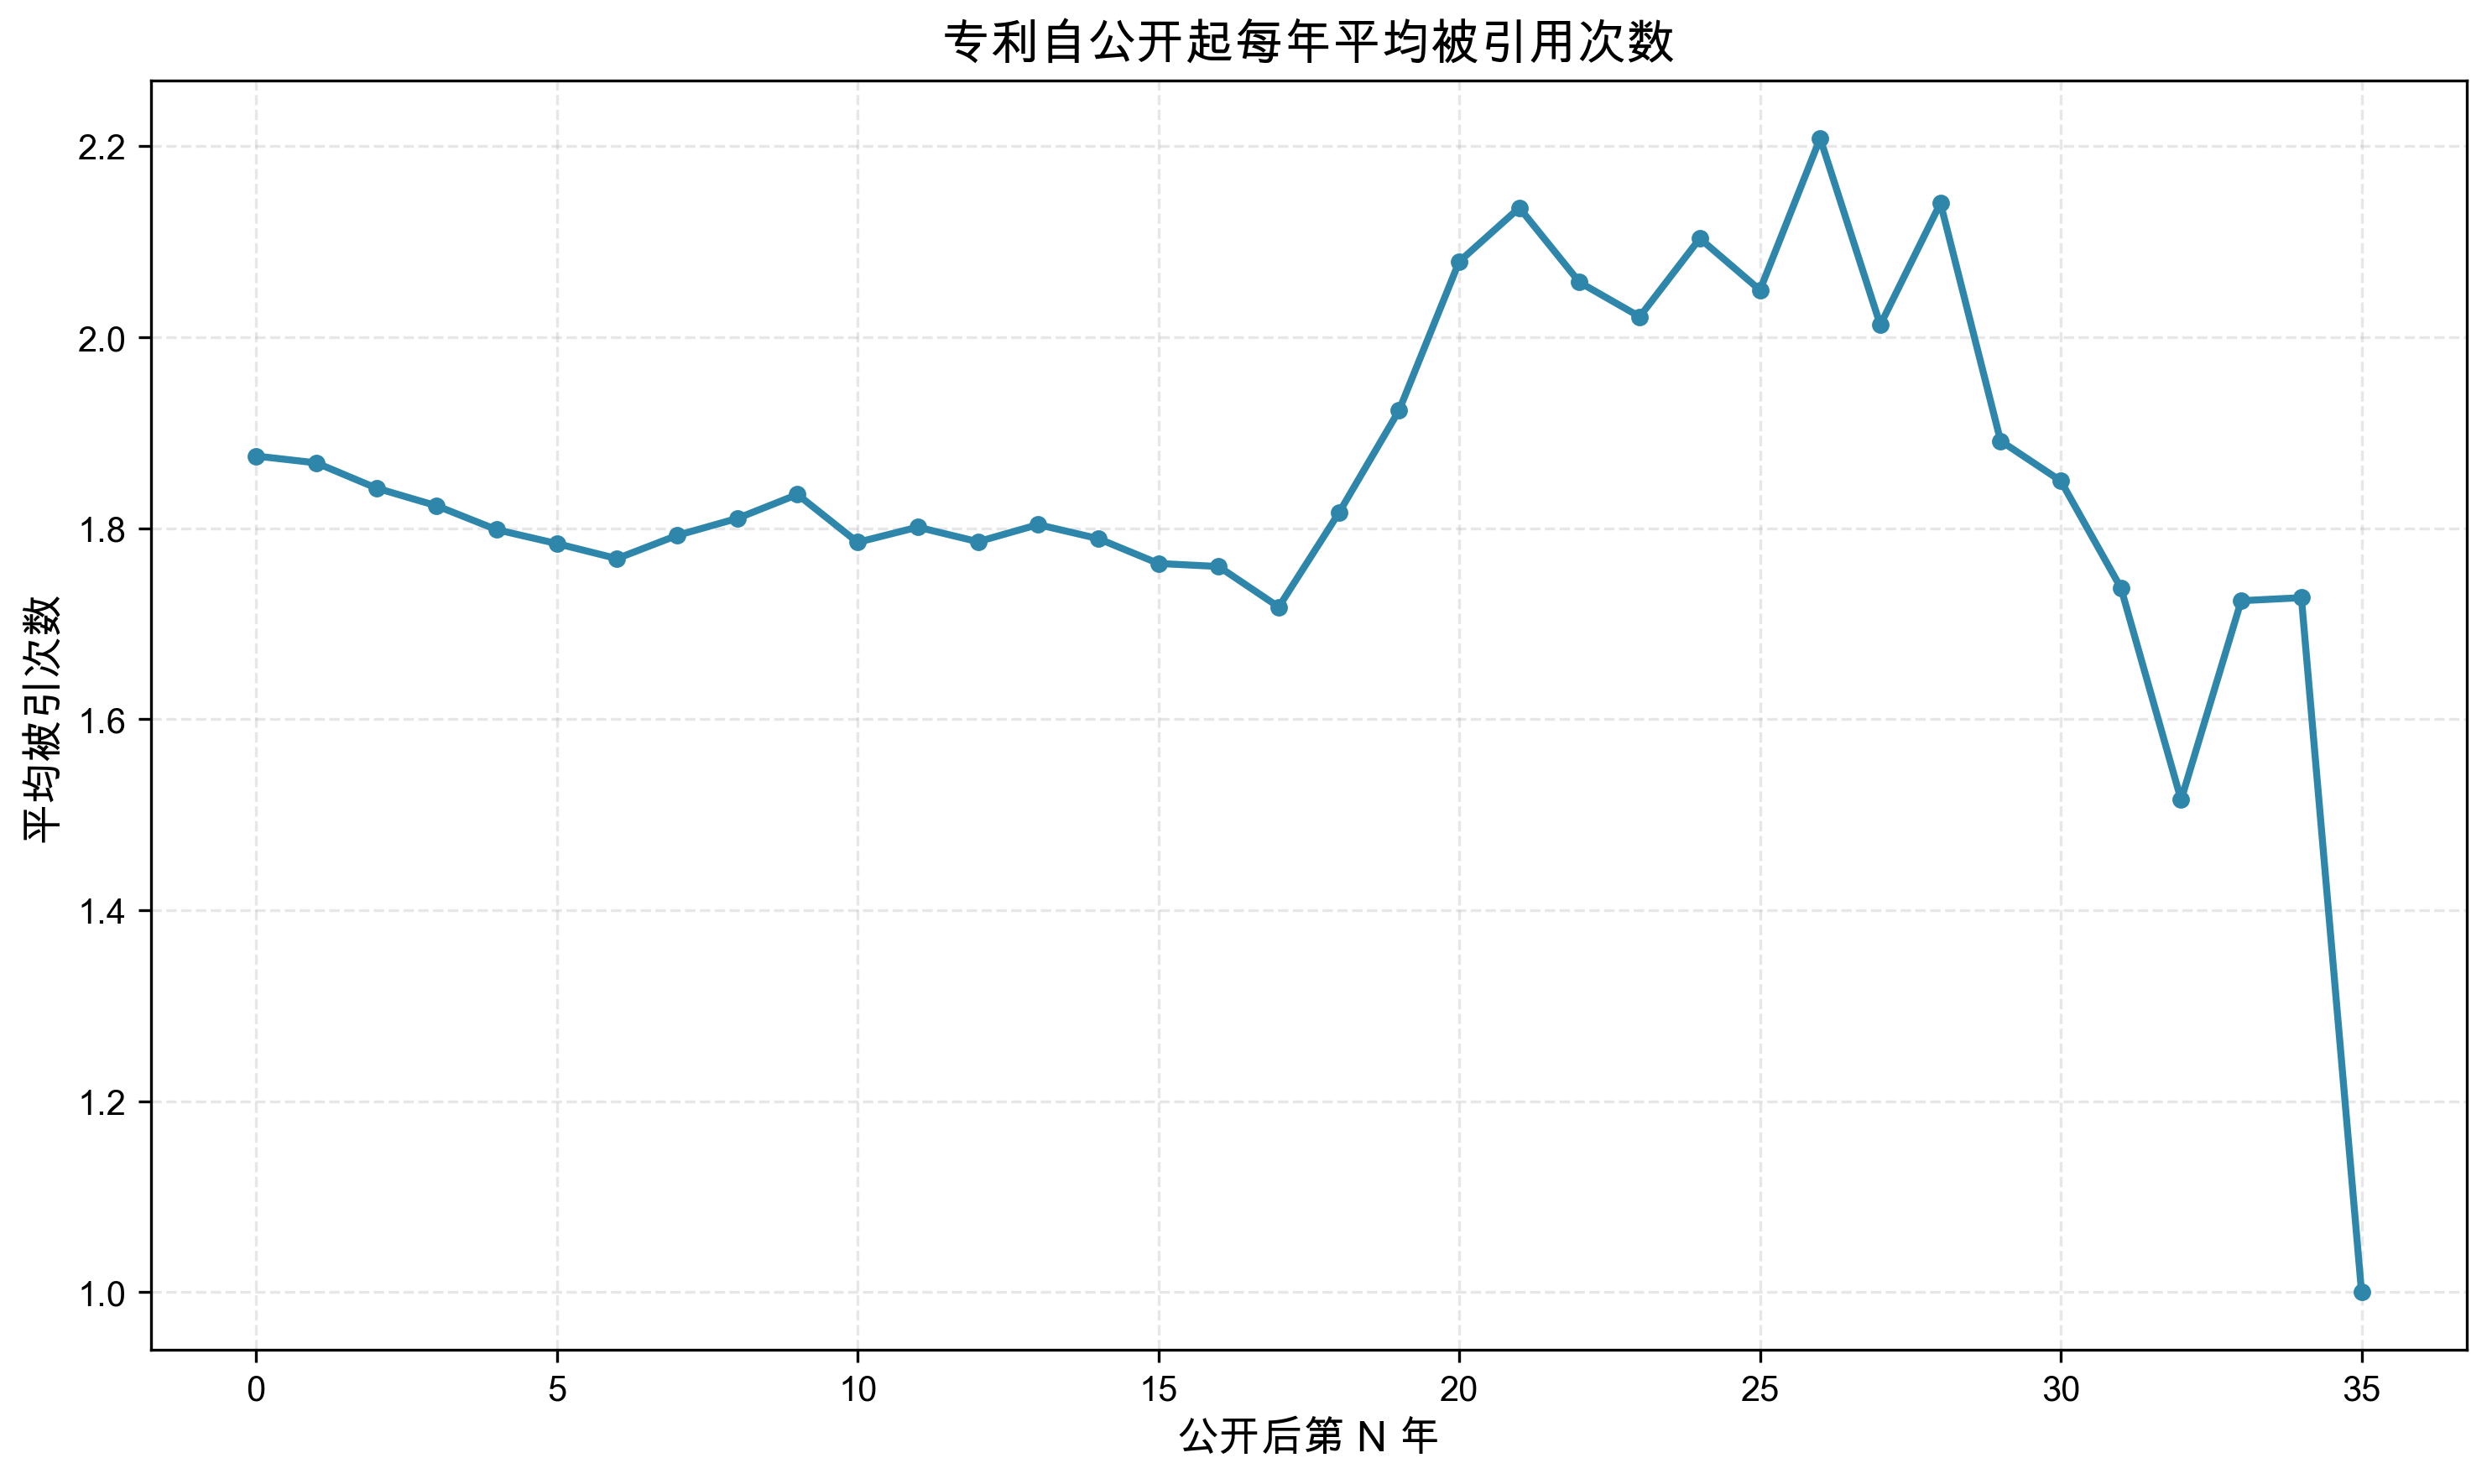

图片已保存


In [142]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# 关键：Mac 系统字体配置（解决乱码）
# ----------------------
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS"]  # Mac 自带中文字体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# ----------------------
# 1. 计算「公开后几年被引用」
# ----------------------
df_final["公开后年数"] = df_final["被引专利申请年"] - df_final["公开年"]
df_final = df_final[df_final["公开后年数"] >= 0].copy()  # 只保留公开后的引用

# 按「申请号+公开后年数」统计被引次数，再求平均
cite_count = df_final.groupby(["申请号", "公开后年数"]).size().reset_index(name="被引次数")
avg_cite = cite_count.groupby("公开后年数")["被引次数"].mean().reset_index()

# ----------------------
# 2. 画图 + 高清保存（带标题，适配Mac）
# ----------------------
plt.figure(figsize=(10, 6), dpi=300)  # 300dpi 高清分辨率

# 画折线
plt.plot(avg_cite["公开后年数"], avg_cite["被引次数"],
         marker='o', linewidth=2, markersize=4, color="#2E86AB")

# 设置标题和坐标轴标签（现在中文能正常显示了）
plt.title("专利自公开起每年平均被引用次数", fontsize=14, fontweight='bold')
plt.xlabel("公开后第 N 年", fontsize=12)
plt.ylabel("平均被引次数", fontsize=12)

# 辅助线和布局
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

# 保存为高清PNG（可直接插入论文）
plt.savefig("专利被引时间趋势图-年份.png", dpi=300, bbox_inches="tight")
plt.show()

print("图片已保存")

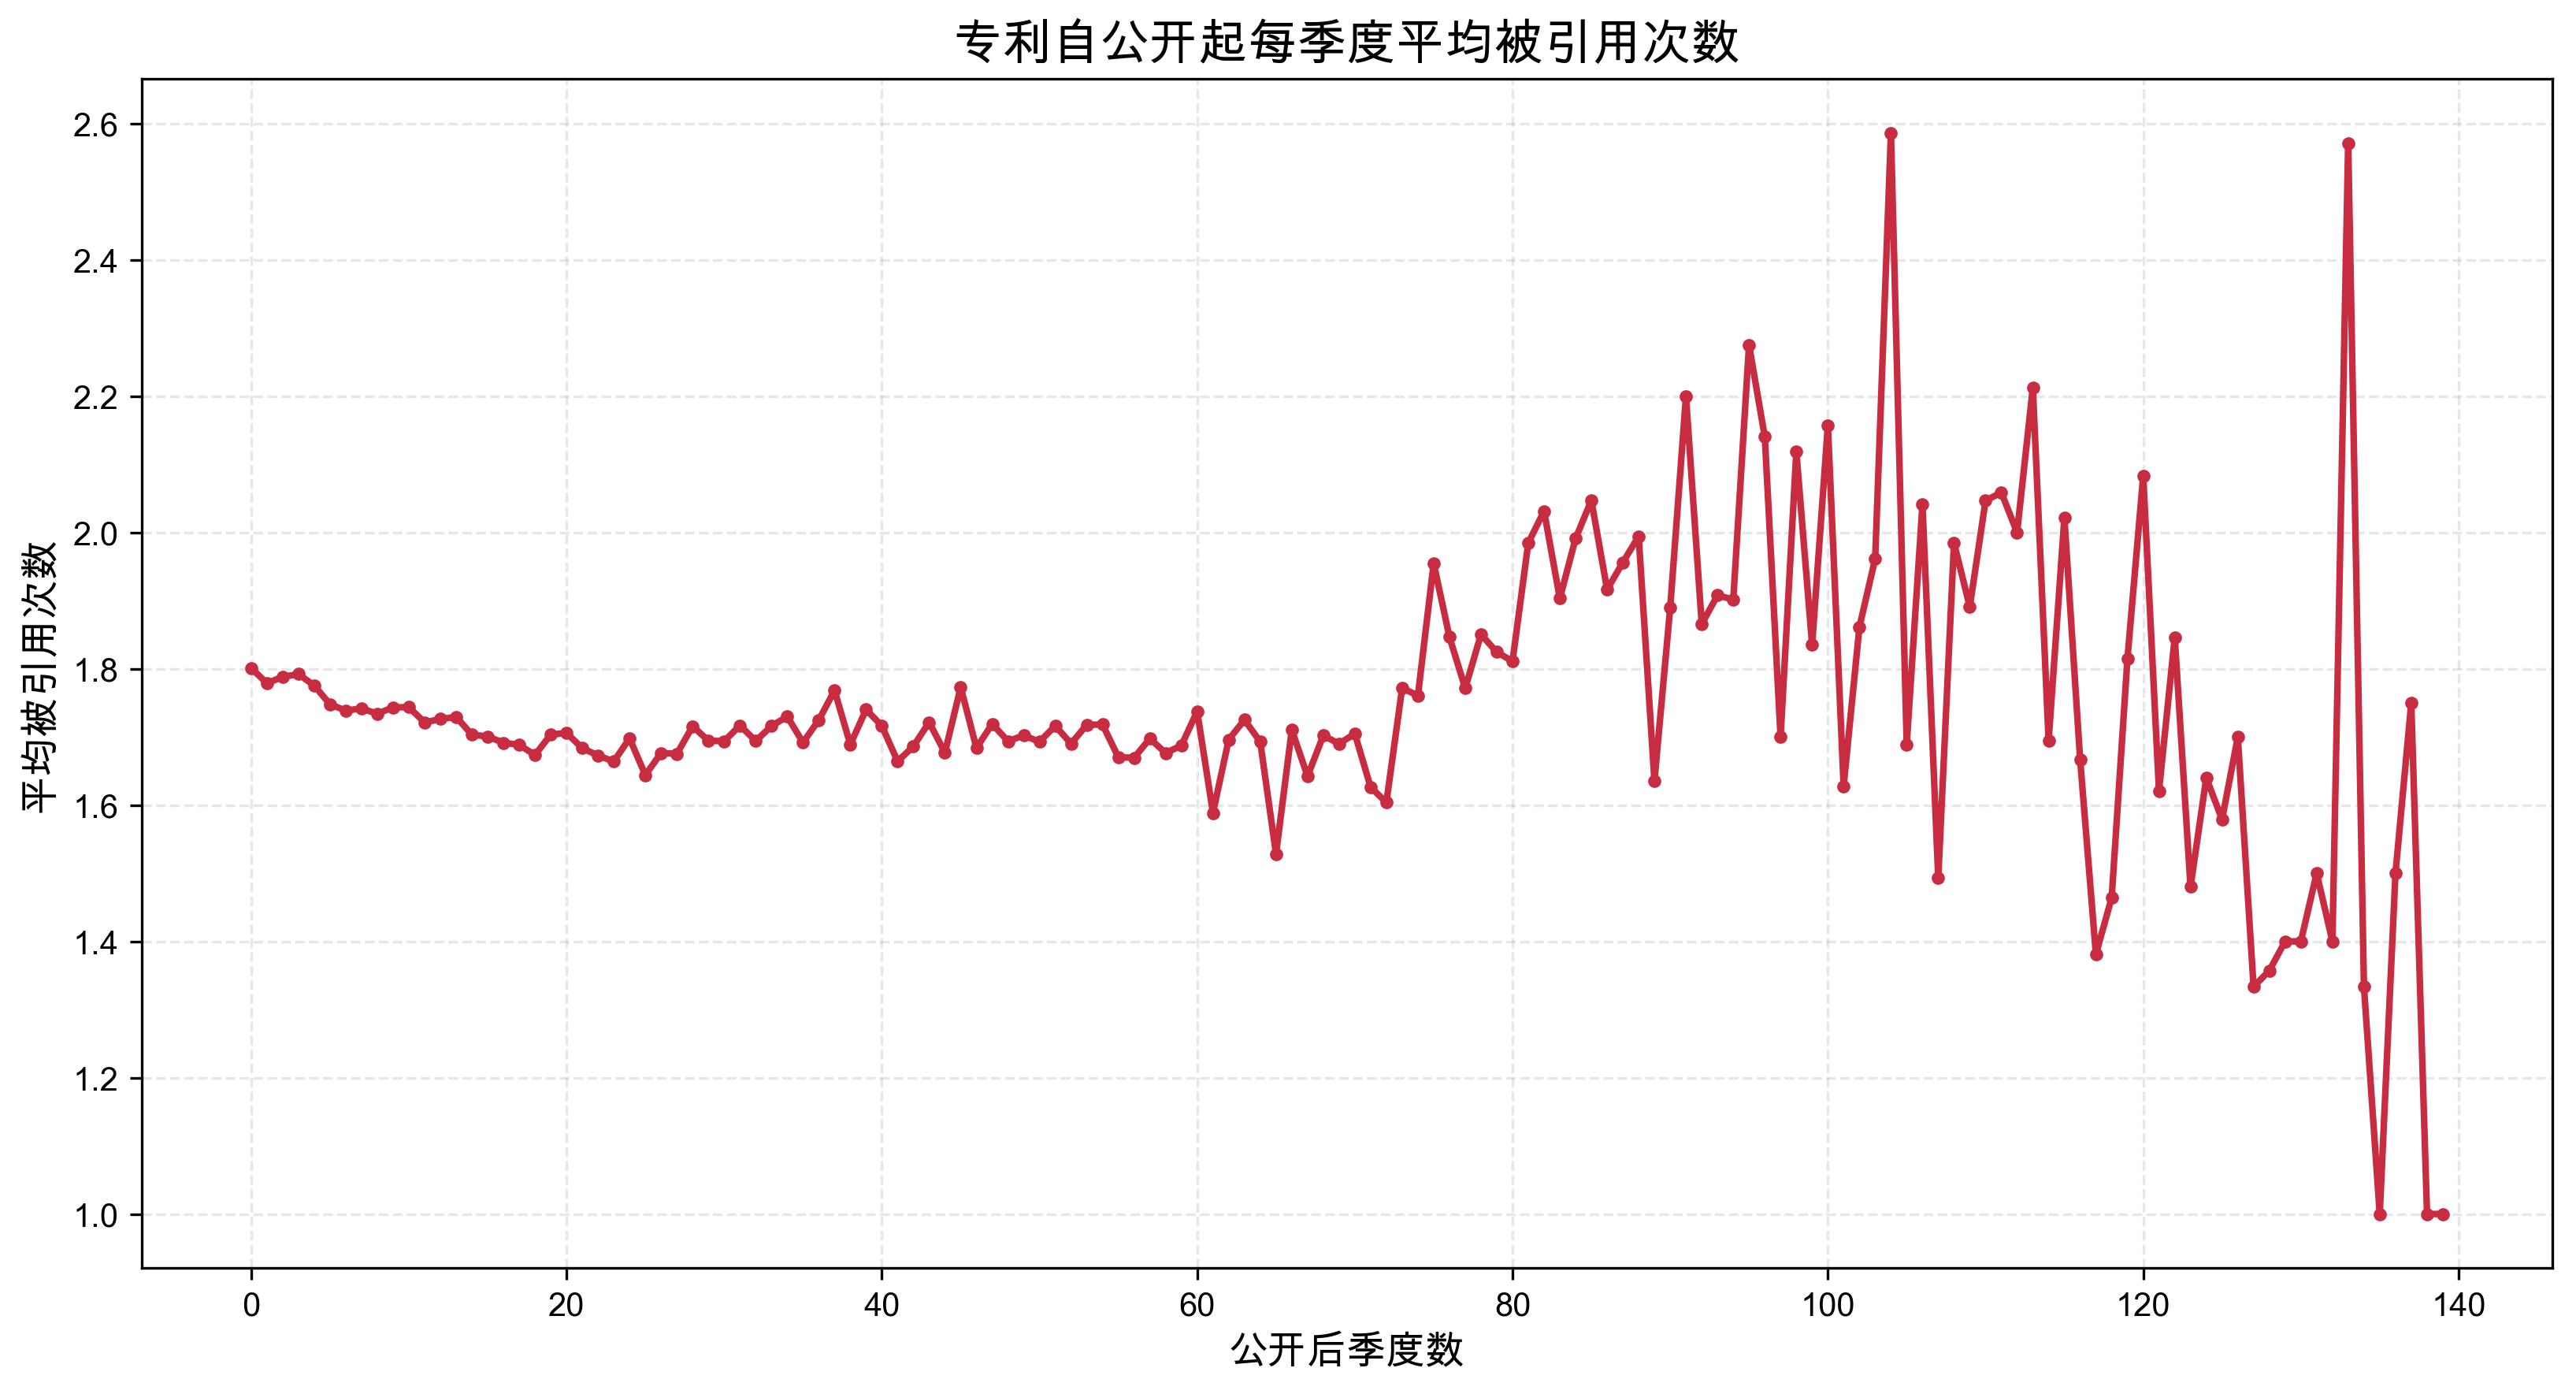

季度趋势图已保存


In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Mac 中文不乱码设置（必须加）
# ==============================
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# ==============================
# 1. 计算 公开后 第几个季度被引用
# ==============================
# 把季度字符串转成时间格式
df_final["公开季度_期"] = pd.PeriodIndex(df_final["公开季度"], freq="Q")
df_final["被引季度_期"] = pd.PeriodIndex(df_final["被引专利申请季度"], freq="Q")

# 计算相差几个季度
df_final["公开后季度数"] = (df_final["被引季度_期"] - df_final["公开季度_期"]).apply(lambda x: x.n)

# 只保留 公开后被引用（排除异常负数）
df_final = df_final[df_final["公开后季度数"] >= 0].copy()

# ==============================
# 2. 按季度统计平均被引次数
# ==============================
# 每个专利每季度被引几次
cite_by_q = df_final.groupby(["申请号", "公开后季度数"]).size().reset_index(name="被引次数")

# 每个季度的平均值
avg_cite_q = cite_by_q.groupby("公开后季度数")["被引次数"].mean().reset_index()

# ==============================
# 3. 画图 + 高清保存（带标题）
# ==============================
plt.figure(figsize=(11, 6), dpi=300)

plt.plot(
    avg_cite_q["公开后季度数"],
    avg_cite_q["被引次数"],
    marker="o",
    color="#c72c41",
    linewidth=2,
    markersize=3
)

plt.title("专利自公开起每季度平均被引用次数", fontsize=15, fontweight="bold")
plt.xlabel("公开后季度数", fontsize=12)
plt.ylabel("平均被引用次数", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

# 保存高清图片
plt.savefig("专利被引时间趋势图-季度.png", dpi=300, bbox_inches="tight")
plt.show()

print("季度趋势图已保存")